In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/15] | Train Acc: 0.8049 | Val Acc: 0.8760
Epoch [2/15] | Train Acc: 0.9288 | Val Acc: 0.9126
Epoch [3/15] | Train Acc: 0.9324 | Val Acc: 0.9329
Epoch [4/15] | Train Acc: 0.9386 | Val Acc: 0.9268
Epoch [5/15] | Train Acc: 0.9222 | Val Acc: 0.8720
Epoch [6/15] | Train Acc: 0.9396 | Val Acc: 0.9614
Epoch [7/15] | Train Acc: 0.9421 | Val Acc: 0.9776
Epoch [8/15] | Train Acc: 0.9017 | Val Acc: 0.9370
Epoch [9/15] | Train Acc: 0.9242 | Val Acc: 0.9472
Epoch [10/15] | Train Acc: 0.9073 | Val Acc: 0.9715
Epoch [11/15] | Train Acc: 0.9544 | Val Acc: 0.9695
Epoch [12/15] | Train Acc: 0.9677 | Val Acc: 0.9350
Epoch [13/15] | Train Acc: 0.9611 | Val Acc: 0.9634
Epoch [14/15] | Train Acc: 0.9636 | Val Acc: 0.9492
Epoch [15/15] | Train Acc: 0.9631 | Val Acc: 0.9715


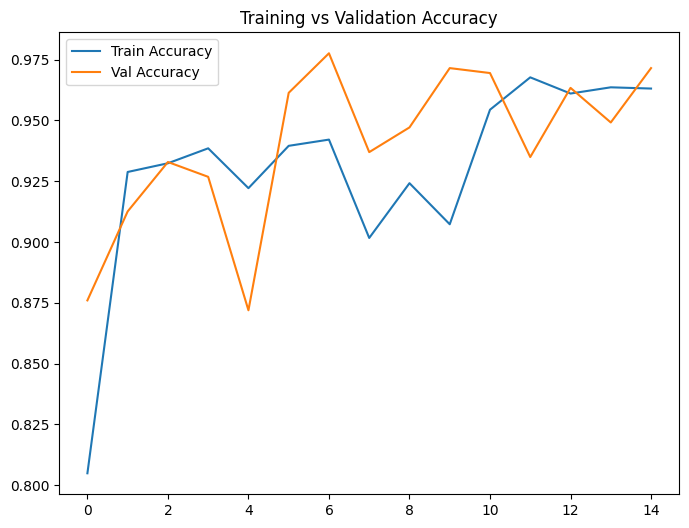

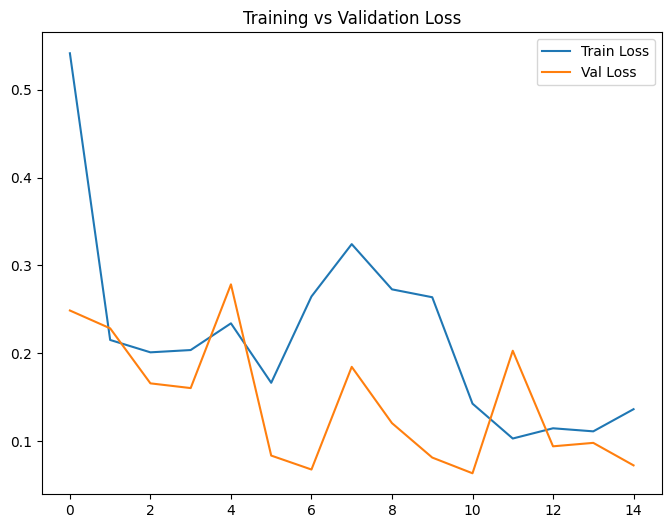

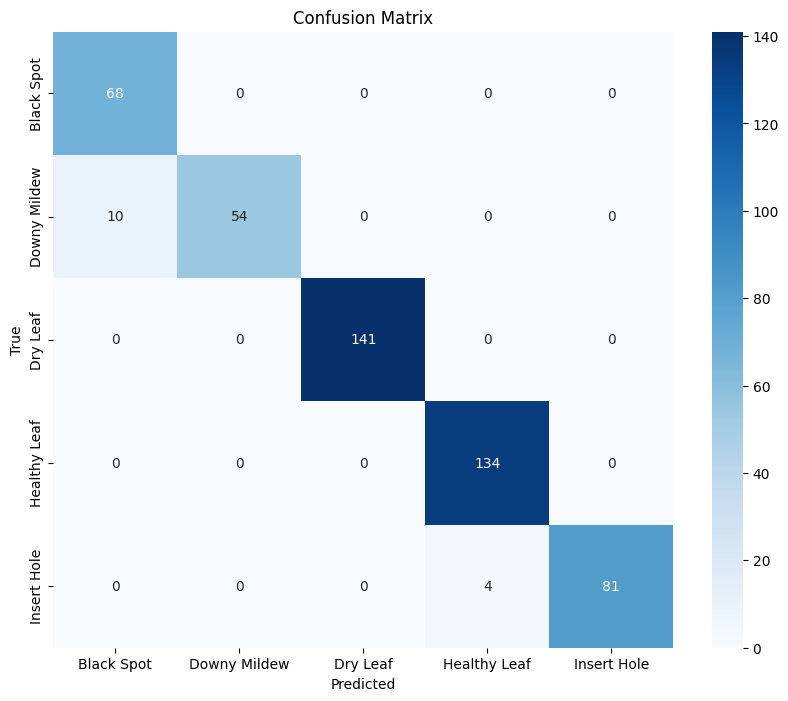

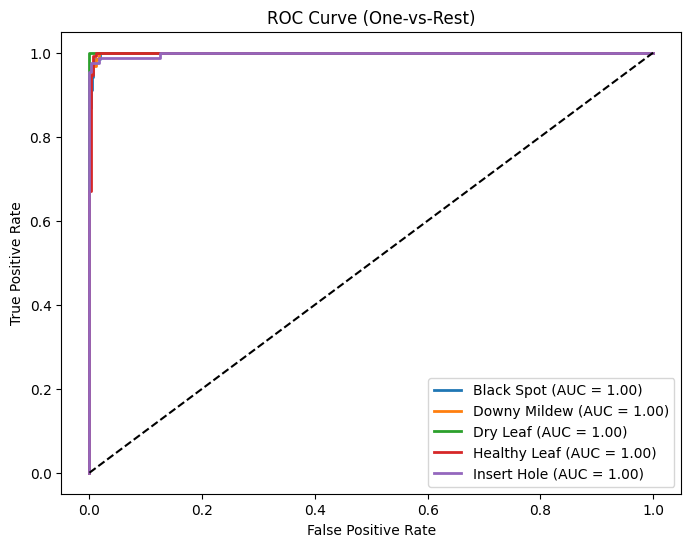



Final Result Table:

Model		Class Name	Precision	Recall	F1-score	Test Accuracy
ResNet-50 without data augmentation
	Black Spot	0.87	1.00	0.93	97.15 %
	Downy Mildew	1.00	0.84	0.92	
	Dry Leaf	1.00	1.00	1.00	
	Healthy Leaf	0.97	1.00	0.99	
	Insert Hole	1.00	0.95	0.98	


In [4]:
# ===============================================
# 📘 Rose Leaf Disease Classification (ResNet50)
# ===============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from itertools import cycle

# ============================
# 1️⃣ Dataset paths
# ============================
train_dir = "/kaggle/input/preprocessed-rose-leaf-dataset/Precessed_Rose_Leaf_Dataset/Train"
test_dir = "/kaggle/input/preprocessed-rose-leaf-dataset/Precessed_Rose_Leaf_Dataset/Test"

# ============================
# 2️⃣ Transformations
# ============================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# ============================
# 3️⃣ Datasets & Dataloaders
# ============================
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

# ============================
# 4️⃣ Model Setup (ResNet50)
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ============================
# 5️⃣ Training Loop
# ============================
num_epochs = 15
train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_acc = correct / total

    # Validation/Test phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / len(test_loader)
    val_epoch_acc = val_correct / val_total

    train_loss.append(train_epoch_loss)
    val_loss.append(val_epoch_loss)
    train_acc.append(train_epoch_acc)
    val_acc.append(val_epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")

# ============================
# 6️⃣ Accuracy & Loss Curves
# ============================
plt.figure(figsize=(8,6))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# ============================
# 7️⃣ Evaluation
# ============================
model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (One-vs-Rest)
y_true_bin = np.eye(num_classes)[y_true]
fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = cycle(plt.cm.tab10.colors)
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ============================
# 8️⃣ Classification Report
# ============================
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

test_accuracy = (np.array(y_true) == np.array(y_pred)).mean() * 100

# Format like example
formatted = df_report[['precision', 'recall', 'f1-score']].iloc[:-3]
formatted = formatted.rename(columns={'precision':'Precision', 'recall':'Recall', 'f1-score':'F1-score'})
formatted.insert(0, 'Class Name', class_names)
formatted['Test Accuracy'] = [f"{test_accuracy:.2f} %" if i==0 else "" for i in range(len(formatted))]

print("\n\nFinal Result Table:\n")
print("Model\t\tClass Name\tPrecision\tRecall\tF1-score\tTest Accuracy")
print("ResNet-50 without data augmentation")

for i, row in formatted.iterrows():
    print(f"\t{row['Class Name']}\t{row['Precision']:.2f}\t{row['Recall']:.2f}\t{row['F1-score']:.2f}\t{row['Test Accuracy']}")



Epoch [1/15] | Train Acc: 0.8162 | Val Acc: 0.9431
Epoch [2/15] | Train Acc: 0.8863 | Val Acc: 0.7927
Epoch [3/15] | Train Acc: 0.9002 | Val Acc: 0.9451
Epoch [4/15] | Train Acc: 0.9155 | Val Acc: 0.9207
Epoch [5/15] | Train Acc: 0.9493 | Val Acc: 0.9736
Epoch [6/15] | Train Acc: 0.9452 | Val Acc: 0.9654
Epoch [7/15] | Train Acc: 0.9467 | Val Acc: 0.9268
Epoch [8/15] | Train Acc: 0.9427 | Val Acc: 0.9492
Epoch [9/15] | Train Acc: 0.9478 | Val Acc: 0.9553
Epoch [10/15] | Train Acc: 0.9391 | Val Acc: 0.9533
Epoch [11/15] | Train Acc: 0.9401 | Val Acc: 0.9350
Epoch [12/15] | Train Acc: 0.9580 | Val Acc: 0.9553
Epoch [13/15] | Train Acc: 0.9683 | Val Acc: 0.9045
Epoch [14/15] | Train Acc: 0.9345 | Val Acc: 0.9553
Epoch [15/15] | Train Acc: 0.9345 | Val Acc: 0.9370


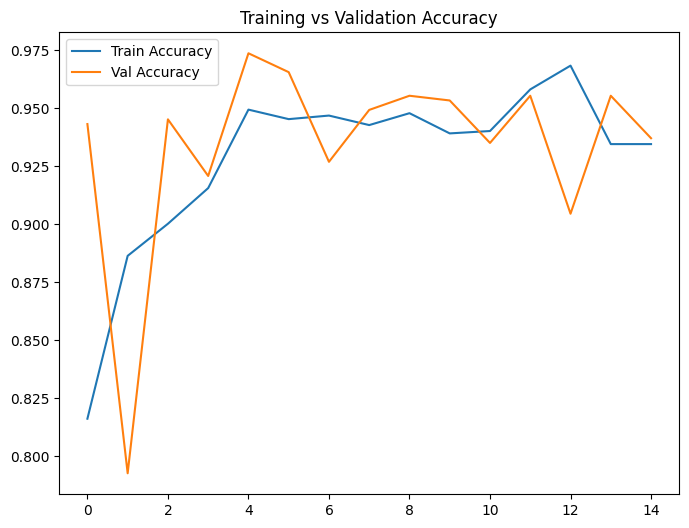

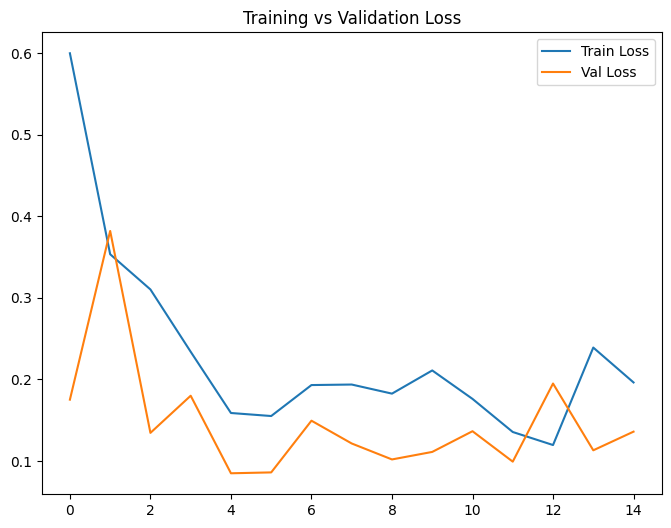

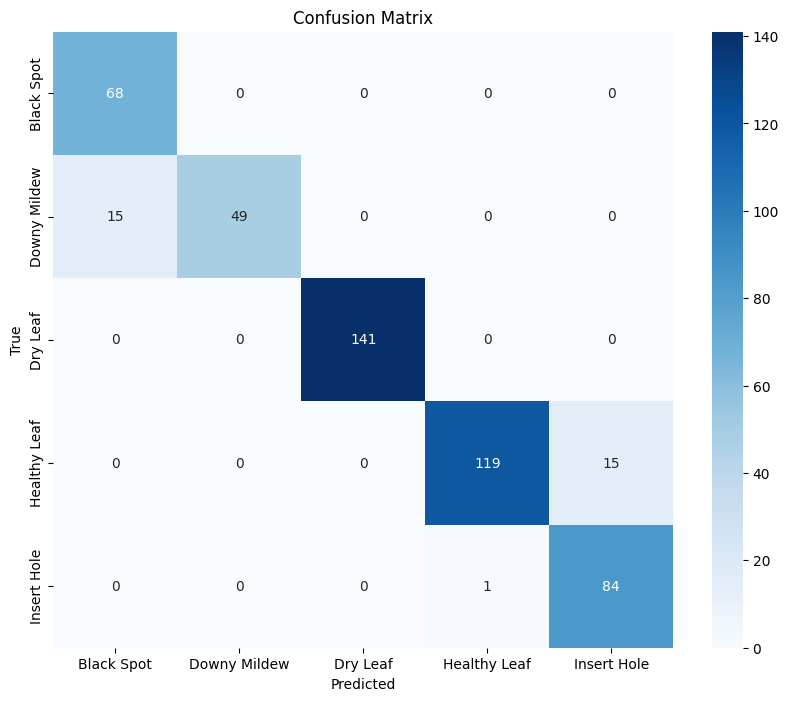

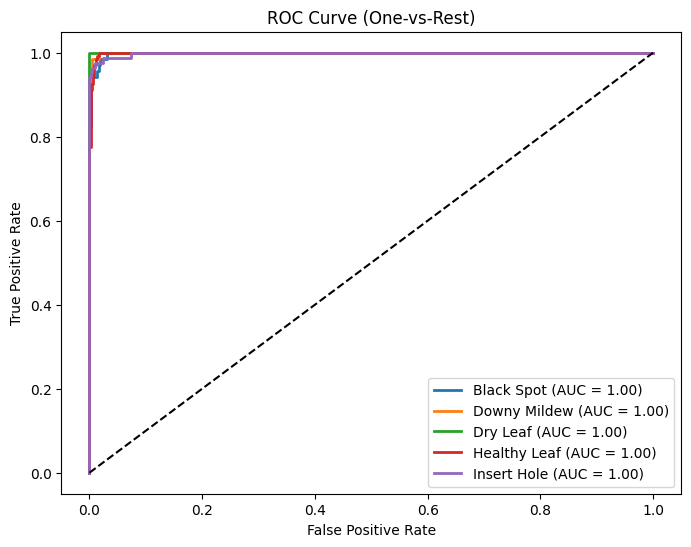



Final Result Table:

Model		Class Name	Precision	Recall	F1-score	Test Accuracy
ResNet-50 without data augmentation
	Black Spot	0.82	1.00	0.90	93.70 %
	Downy Mildew	1.00	0.77	0.87	
	Dry Leaf	1.00	1.00	1.00	
	Healthy Leaf	0.99	0.89	0.94	
	Insert Hole	0.85	0.99	0.91	


In [2]:
# ===============================================
# 📘 Rose Leaf Disease Classification (ResNet50)
# ===============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from itertools import cycle

# ============================
# 1️⃣ Dataset paths
# ============================
train_dir = "/kaggle/input/preprocessed-rose-leaf-dataset/Precessed_Rose_Leaf_Dataset/Train"
test_dir = "/kaggle/input/preprocessed-rose-leaf-dataset/Precessed_Rose_Leaf_Dataset/Test"

# ============================
# 2️⃣ Transformations
# ============================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# ============================
# 3️⃣ Datasets & Dataloaders
# ============================
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

# ============================
# 4️⃣ Model Setup (ResNet50)
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ============================
# 5️⃣ Training Loop
# ============================
num_epochs = 15
train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_acc = correct / total

    # Validation/Test phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / len(test_loader)
    val_epoch_acc = val_correct / val_total

    train_loss.append(train_epoch_loss)
    val_loss.append(val_epoch_loss)
    train_acc.append(train_epoch_acc)
    val_acc.append(val_epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")

# ============================
# 6️⃣ Accuracy & Loss Curves
# ============================
plt.figure(figsize=(8,6))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# ============================
# 7️⃣ Evaluation
# ============================
model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (One-vs-Rest)
y_true_bin = np.eye(num_classes)[y_true]
fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = cycle(plt.cm.tab10.colors)
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ============================
# 8️⃣ Classification Report
# ============================
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

test_accuracy = (np.array(y_true) == np.array(y_pred)).mean() * 100

# Format like example
formatted = df_report[['precision', 'recall', 'f1-score']].iloc[:-3]
formatted = formatted.rename(columns={'precision':'Precision', 'recall':'Recall', 'f1-score':'F1-score'})
formatted.insert(0, 'Class Name', class_names)
formatted['Test Accuracy'] = [f"{test_accuracy:.2f} %" if i==0 else "" for i in range(len(formatted))]

print("\n\nFinal Result Table:\n")
print("Model\t\tClass Name\tPrecision\tRecall\tF1-score\tTest Accuracy")
print("ResNet-50 without data augmentation")

for i, row in formatted.iterrows():
    print(f"\t{row['Class Name']}\t{row['Precision']:.2f}\t{row['Recall']:.2f}\t{row['F1-score']:.2f}\t{row['Test Accuracy']}")



In [8]:
import pandas as pd
import numpy as np

# ✅ Best epoch calculation
best_epoch = np.argmax(val_acc)
best_train_acc = train_acc[best_epoch] * 100
best_test_acc = val_acc[best_epoch] * 100

print(f"\n✅ Best Epoch Summary:")
print(f"Best Epoch: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_acc:.2f}%")
print(f"Test Accuracy at Best Epoch: {best_test_acc:.2f}%")

# ✅ Build classification result table
formatted = df_report[['precision', 'recall', 'f1-score']].iloc[:-3].copy()
formatted = formatted.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1-score'
})
formatted.insert(0, 'Class Name', class_names)

# ✅ Insert the model name only once (first row)
formatted.insert(0, 'Model', [""] * len(formatted))
formatted.loc[0, 'Model'] = "ResNet-50 without data augmentation"

# ✅ Insert Accuracy column — only first row has the overall test acc
formatted['Accuracy'] = [""] * len(formatted)
formatted.loc[0, 'Accuracy'] = f"{best_test_acc:.2f} %"

# ✅ Print table in academic format
print("\n{:<35}{:<20}{:<12}{:<12}{:<12}{}".format("Model", "Class Name", "Precision", "Recall", "F1-score", "Accuracy"))
print("-" * 105)
for _, row in formatted.iterrows():
    print("{:<35}{:<20}{:<12.2f}{:<12.2f}{:<12.2f}{}".format(
        row['Model'], row['Class Name'], row['Precision'], row['Recall'], row['F1-score'], row['Accuracy']
    ))

# ✅ Highest performing class
best_class = formatted.loc[formatted['F1-score'].idxmax()]
print("\n🏆 Highest Accuracy Class:")
print(f"{best_class['Class Name']} — F1-score: {best_class['F1-score']:.2f}")



✅ Best Epoch Summary:
Best Epoch: 5
Train Accuracy at Best Epoch: 94.93%
Test Accuracy at Best Epoch: 97.36%

Model                              Class Name          Precision   Recall      F1-score    Accuracy
---------------------------------------------------------------------------------------------------------
                                   Black Spot          0.82        1.00        0.90        
                                   Downy Mildew        1.00        0.77        0.87        
                                   Dry Leaf            1.00        1.00        1.00        
                                   Healthy Leaf        0.99        0.89        0.94        
                                   Insert Hole         0.85        0.99        0.91        
ResNet-50 without data augmentationnan                 nan         nan         nan         97.36 %

🏆 Highest Accuracy Class:
Dry Leaf — F1-score: 1.00


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Epoch [1/10] | Train Acc: 0.9150 | Val Acc: 0.9735
Epoch [2/10] | Train Acc: 0.9584 | Val Acc: 0.9532
Epoch [3/10] | Train Acc: 0.9575 | Val Acc: 0.9776
Epoch [4/10] | Train Acc: 0.9670 | Val Acc: 0.9776
Epoch [5/10] | Train Acc: 0.9634 | Val Acc: 0.9756
Epoch [6/10] | Train Acc: 0.9667 | Val Acc: 0.9654
Epoch [7/10] | Train Acc: 0.9715 | Val Acc: 0.9756
Epoch [8/10] | Train Acc: 0.9685 | Val Acc: 0.9776
Epoch [9/10] | Train Acc: 0.9760 | Val Acc: 0.9857
Epoch [10/10] | Train Acc: 0.9770 | Val Acc: 0.9654


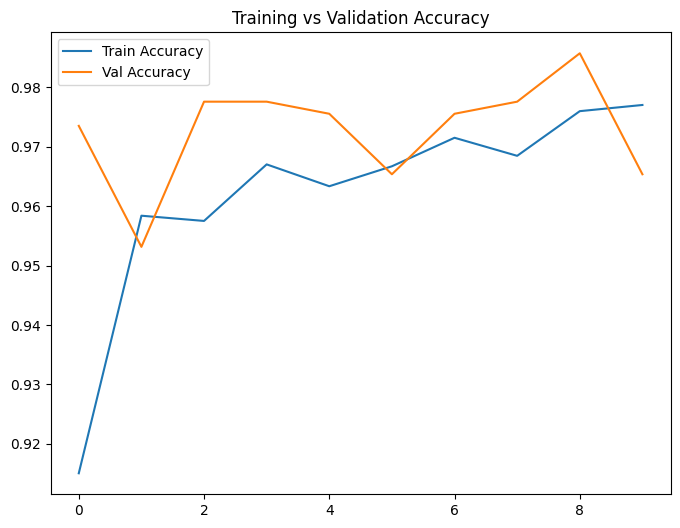

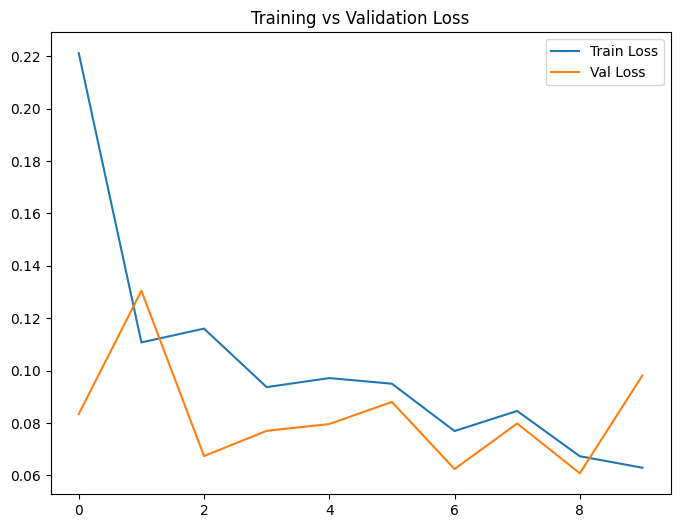

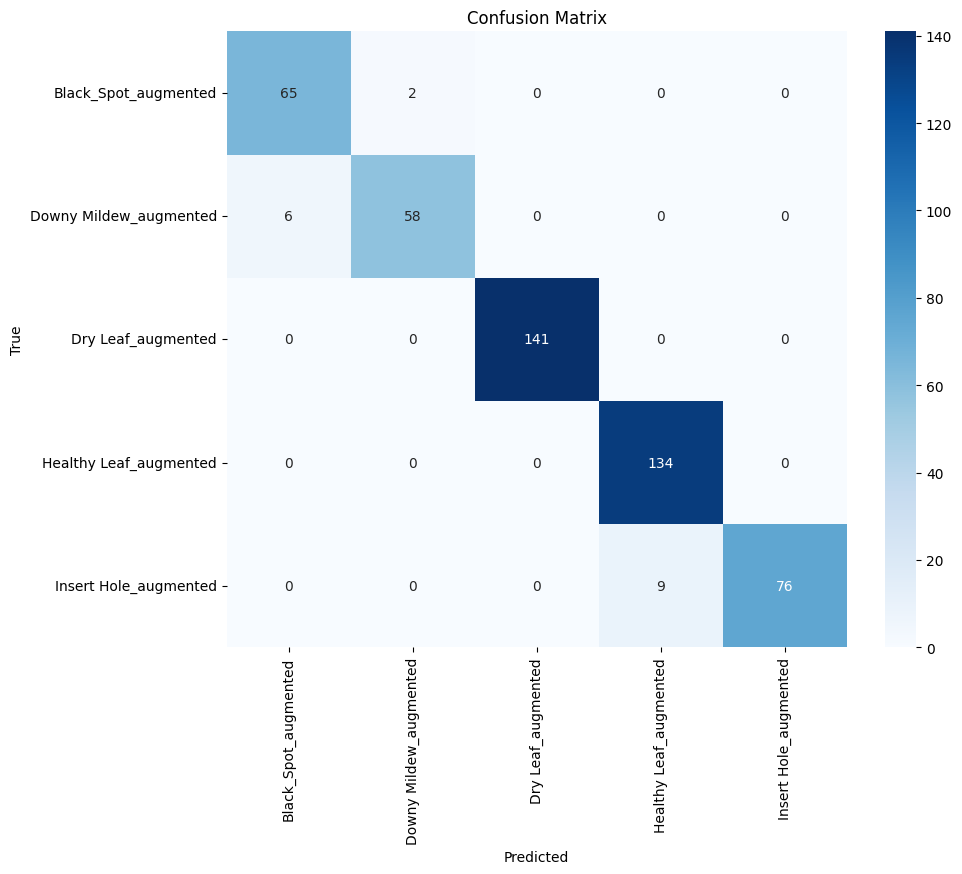

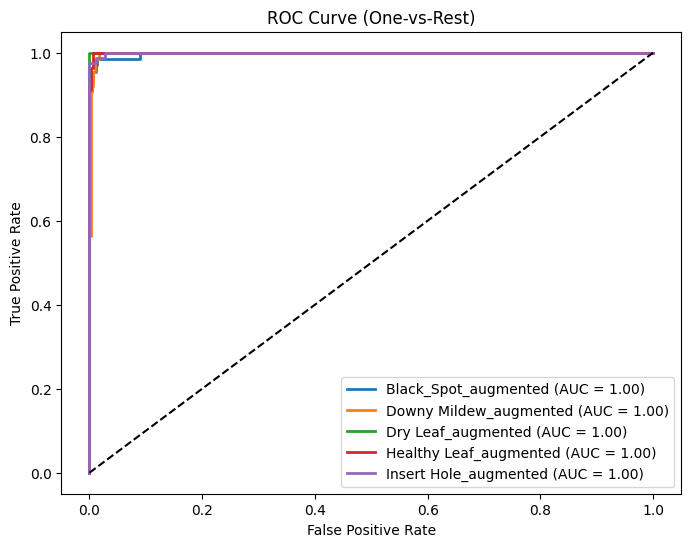


✅ Best Epoch Summary:
Best Epoch: 9
Train Accuracy at Best Epoch: 97.60%
Test Accuracy at Best Epoch: 98.57%


NameError: name 'df_report' is not defined

In [1]:
# ===============================================
# 📘 Rose Leaf Disease Classification (ResNet50)
# ===============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from itertools import cycle

# ============================
# 1️⃣ Dataset paths
# ============================
train_dir = "/kaggle/input/augmented-train-rose-leaf-dataset/Augmented_Train_Rose_Leaf_Dataset/Train"
test_dir = "/kaggle/input/augmented-train-rose-leaf-dataset/Augmented_Train_Rose_Leaf_Dataset/Test"

# ============================
# 2️⃣ Transformations
# ============================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# ============================
# 3️⃣ Datasets & Dataloaders
# ============================
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

# ============================
# 4️⃣ Model Setup (ResNet50)
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ============================
# 5️⃣ Training Loop
# ============================
num_epochs = 10
train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_acc = correct / total

    # Validation/Test phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / len(test_loader)
    val_epoch_acc = val_correct / val_total

    train_loss.append(train_epoch_loss)
    val_loss.append(val_epoch_loss)
    train_acc.append(train_epoch_acc)
    val_acc.append(val_epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")

# ============================
# 6️⃣ Accuracy & Loss Curves
# ============================
plt.figure(figsize=(8,6))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# ============================
# 7️⃣ Evaluation
# ============================
model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (One-vs-Rest)
y_true_bin = np.eye(num_classes)[y_true]
fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = cycle(plt.cm.tab10.colors)
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ============================
# 8️⃣ Classification Report
# ============================
import pandas as pd
import numpy as np

# ✅ Best epoch calculation
best_epoch = np.argmax(val_acc)
best_train_acc = train_acc[best_epoch] * 100
best_test_acc = val_acc[best_epoch] * 100

print(f"\n✅ Best Epoch Summary:")
print(f"Best Epoch: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_acc:.2f}%")
print(f"Test Accuracy at Best Epoch: {best_test_acc:.2f}%")

# ✅ Build classification result table
formatted = df_report[['precision', 'recall', 'f1-score']].iloc[:-3].copy()
formatted = formatted.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1-score'
})
formatted.insert(0, 'Class Name', class_names)

# ✅ Insert the model name only once (first row)
formatted.insert(0, 'Model', [""] * len(formatted))
formatted.loc[0, 'Model'] = "ResNet-50 without data augmentation"

# ✅ Insert Accuracy column — only first row has the overall test acc
formatted['Accuracy'] = [""] * len(formatted)
formatted.loc[0, 'Accuracy'] = f"{best_test_acc:.2f} %"

# ✅ Print table in academic format
print("\n{:<35}{:<20}{:<12}{:<12}{:<12}{}".format("Model", "Class Name", "Precision", "Recall", "F1-score", "Accuracy"))
print("-" * 105)
for _, row in formatted.iterrows():
    print("{:<35}{:<20}{:<12.2f}{:<12.2f}{:<12.2f}{}".format(
        row['Model'], row['Class Name'], row['Precision'], row['Recall'], row['F1-score'], row['Accuracy']
    ))

# ✅ Highest performing class
best_class = formatted.loc[formatted['F1-score'].idxmax()]
print("\n🏆 Highest Accuracy Class:")
print(f"{best_class['Class Name']} — F1-score: {best_class['F1-score']:.2f}")


In [3]:
# ============================
# 8️⃣ Classification Report
# ============================
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# ✅ Best epoch calculation
best_epoch = np.argmax(val_acc)
best_train_acc = train_acc[best_epoch] * 100
best_test_acc = val_acc[best_epoch] * 100


# ✅ Clean and aligned table printout
print("\n✅ Best Epoch Summary:")
print(f"Best Epoch: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_acc:.2f}%")
print(f"Test Accuracy at Best Epoch: {best_test_acc:.2f}%\n")

# Table Header
print(f"{'Model':<35}{'Class Name':<25}{'Precision':<12}{'Recall':<12}{'F1-score':<12}{'Accuracy'}")
print("-" * 110)

# Print model name once, followed by class metrics
print(f"{'ResNet-50 without data augmentation':<35}", end="")

first = True
for i, row in formatted.iterrows():
    if not first:
        print(f"{'':<35}", end="")  # skip repeating model name
    print(f"{row['Class Name']:<25}{row['Precision']:<12.2f}{row['Recall']:<12.2f}{row['F1-score']:<12.2f}", end="")
    if first:
        print(f"{best_test_acc:.2f} %")
        first = False
    else:
        print("")

print("-" * 110)
print(f"\n🏆 Highest Accuracy Class: {best_class['Class Name']} — F1-score: {best_class['F1-score']:.2f}")



✅ Best Epoch Summary:
Best Epoch: 9
Train Accuracy at Best Epoch: 97.60%
Test Accuracy at Best Epoch: 98.57%

Model                              Class Name               Precision   Recall      F1-score    Accuracy
--------------------------------------------------------------------------------------------------------------
ResNet-50 without data augmentationBlack_Spot_augmented     0.92        0.97        0.94        98.57 %
                                   Downy Mildew_augmented   0.97        0.91        0.94        
                                   Dry Leaf_augmented       1.00        1.00        1.00        
                                   Healthy Leaf_augmented   0.94        1.00        0.97        
                                   Insert Hole_augmented    1.00        0.89        0.94        
                                   nan                      nan         nan         nan         
------------------------------------------------------------------------------------